Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
!pip install fuzzywuzzy python-levenshtein
from sklearn.preprocessing import OneHotEncoder
!pip install xgboost
import matplotlib.pyplot as plt
!pip install xgboost
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

from fuzzywuzzy import process  # pip install fuzzywuzzy python-levenshtein


In [ ]:
dataset=pd.read_csv(r"C:\Users\sehga\Desktop\RentEase_04\Indian_House_Rent_Dataset.csv")

In [ ]:
dataset.head()

,Posted On,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent
0,NaN,2.0,1100.0,NaN,Super Area,Bandel,India-! Kolkata,Unfurnished,Bach^elors/Fam.ily,2.0,Contact Owner,10000
1,2022-05-13,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",India-! Kolkata,Semi-Furnished,Bachelors\/Family*,NaN,NaN,20000
2,2022-05-16,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,India-- Kolkata,Semi-Furnished,NaN,1.0,Contact Owner,17000
3,2022-07-04,2.0,800.0,1 out of 2,Super Area,NaN,NaN,Unfurnished,Bachel]ors/F@amily,1.0,NaN,10000
4,2022-05-09,2.0 room,850.0,1 out of 2,Carpet Area,South Dum Dum,India-^ Kolkata,Unfurnished,Bache[lors&,1.0,Contact Owner,7500


In [ ]:
dataset.isnull().sum()


Posted On            662
BHK                  783
Size                 920
Floor                786
Area Type            942
Area Locality        600
City                 655
Furnishing Status    704
Tenant Preferred     652
Bathroom             541
Point of Contact     609
Rent                   0
dtype: int64

In [ ]:
columns_to_drop = ['Point of Contact', 'Tenant Preferred', 'Posted On']


In [ ]:
# Drop the columns
dataset = dataset.drop(columns=columns_to_drop)

# Check the remaining columns
print(dataset.columns)

Index(['BHK', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Bathroom', 'Rent'],
      dtype='object')


In [ ]:
dataset.shape

(4746, 9)

In [ ]:


# Convert to string, extract digits, convert to int
for col in ['BHK', 'Bathroom', 'Floor']:
     dataset[col] =  dataset[col].astype(str).str.extract(r'(\d+)')[0]
     dataset[col] = pd.to_numeric(dataset[col], errors='coerce')  # convert to numeric
     dataset[col] =  dataset[col].fillna(dataset[col].mode()[0])        # fill missing with mode

# For Size (it may be float)
if 'Size' in dataset.columns:
     dataset['Size'] =  dataset['Size'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
     dataset['Size'] = pd.to_numeric(dataset['Size'], errors='coerce')
     dataset['Size'] =  dataset['Size'].fillna(dataset['Size'].median())



In [ ]:
def clean_text(x):
    x = str(x).lower().strip()                     # lowercase & strip
    x = ''.join(c for c in x if c.isalpha() or c.isspace())  # remove numbers & symbols
    return x

categorical_cols = ['City', 'Area Locality', 'Area Type', 'Furnishing Status']

for col in categorical_cols:
    if col in dataset.columns:
        dataset[col] = dataset[col].apply(clean_text)


In [ ]:
# Standard city names
standard_cities = ['mumbai', 'delhi', 'bangalore', 'chennai', 'kolkata', 'hyderabad']

def match_city(x, choices=standard_cities):
    match, score = process.extractOne(x, choices)
    if score >= 80:
        return match
    else:
        return 'other'

if 'City' in dataset.columns:
    dataset['City'] = dataset['City'].apply(match_city)


In [ ]:
if 'Area Locality' in dataset.columns:
    top_localities = dataset['Area Locality'].value_counts().nlargest(30).index
    dataset['Area Locality'] = dataset['Area Locality'].apply(lambda x: x if x in top_localities else 'other')


In [ ]:

# Rent ko 99th percentile par cap karein taaki model confuse na ho
cap = dataset['Rent'].quantile(0.99)
dataset = dataset[dataset['Rent'] <= cap]

In [ ]:
print(dataset.isnull().sum())


BHK                  0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Bathroom             0
Rent                 0
dtype: int64


In [ ]:
print(dataset.dtypes)


BHK                  float64
Size                 float64
Floor                float64
Area Type             object
Area Locality         object
City                  object
Furnishing Status     object
Bathroom             float64
Rent                   int64
dtype: object


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Correct syntax for scikit-learn 1.2+
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Only encode categorical columns
cols_to_encode = [col for col in categorical_cols if col in dataset.columns]

encoded = ohe.fit_transform(dataset[cols_to_encode])
encoded_dataset = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols_to_encode))

# Drop original categorical columns and concat encoded
dataset = dataset.drop(columns=cols_to_encode)
dataset = pd.concat([dataset.reset_index(drop=True), encoded_dataset.reset_index(drop=True)], axis=1)


In [ ]:
# 6. LOG TRANSFORMATION & SPLIT
# Target variable ka log lena overfitting rokne ke liye sabse zaroori hai
from sklearn.model_selection import train_test_split

y = np.log1p(dataset['Rent'])
X = dataset.drop('Rent', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor


In [ ]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("Training is in progress...")
model.fit(X_train, y_train)

Training is in progress...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [70]:
import joblib
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

print("\n--- Final Model Metrics ---")
print(f"R2 Score: {r2_score(y_actual, y_pred):.4f}")
print(f"MAE: ₹{mean_absolute_error(y_actual, y_pred):.2f}")

# 9. SAVE MODELS
joblib.dump(model, 'rentease_final_model_.pkl')
joblib.dump(ohe, 'rentease_final_encoder_.pkl')
print("\nFiles saved: rentease_final_model_.pkl, rentease_final_encoder_.pkl")


--- Final Model Metrics ---
R2 Score: 0.7015
MAE: ₹10587.44

Files saved: rentease_final_model_.pkl, rentease_final_encoder_.pkl


In [71]:
import pickle
import pandas as pd
import numpy as np

# Load trained model
with open("rentease_final_model_.pkl", "rb") as file:
    model = pickle.load(file)

# Model feature list (EXACT order & names)
features = [
    'BHK', 'Size', 'Floor', 'Bathroom',
    'City_bangalore', 'City_chennai', 'City_delhi', 'City_hyderabad', 'City_kolkata',
    'City_mumbai', 'City_other',
    'Area Locality_andheri west', 'Area Locality_bandra west', 'Area Locality_banjara hills nh ',
    'Area Locality_chembur', 'Area Locality_chhattarpur', 'Area Locality_chromepet gst road',
    'Area Locality_electronic city', 'Area Locality_gachibowli', 'Area Locality_goregaon west',
    'Area Locality_jp nagar phase  j p nagar', 'Area Locality_k r puram', 'Area Locality_khar west',
    'Area Locality_kondapur', 'Area Locality_lajpat nagar ', 'Area Locality_laxmi nagar',
    'Area Locality_madipakkam', 'Area Locality_mahadevapura', 'Area Locality_manikonda outer ring road',
    'Area Locality_medavakkam', 'Area Locality_miyapur nh ', 'Area Locality_nan',
    'Area Locality_old mahabalipuram road', 'Area Locality_other',
    'Area Locality_perungalathur chennai bypass road', 'Area Locality_porur',
    'Area Locality_rohini sector ', 'Area Locality_salt lake city sector ',
    'Area Locality_sholinganallur', 'Area Locality_vadapalani',
    'Area Locality_velachery', 'Area Locality_whitefield',
    'Area Type_built area', 'Area Type_carpet area',
    'Area Type_nan', 'Area Type_super area',
    'Furnishing Status_furnished', 'Furnishing Status_nan',
    'Furnishing Status_semifurnished', 'Furnishing Status_unfurnished'
]



In [72]:
def predict_rent(BHK, Size, Floor, Bathroom, City, Locality, AreaType, Furnishing):
    import pandas as pd
    import numpy as np

    # Clean inputs
    City = City.strip().lower()
    Locality = Locality.strip().lower()
    AreaType = AreaType.strip().lower()
    Furnishing = Furnishing.strip().lower()

    # Initialize input dict
    input_dict = {feat: [0] for feat in features}
    input_dict['BHK'] = [BHK]
    input_dict['Size'] = [Size]
    input_dict['Floor'] = [Floor]
    input_dict['Bathroom'] = [Bathroom]

    # --- Safely create mapping dicts ---
    city_map = {}
    locality_map = {}
    area_map = {}
    furnish_map = {}

    for f in features:
        if f.startswith('City_'):
            key = f[len('City_'):].strip().lower()
            city_map[key] = f
        elif f.startswith('Area Locality_'):
            key = f[len('Area Locality_'):].strip().lower()
            locality_map[key] = f
        elif f.startswith('Area Type_'):
            key = f[len('Area Type_'):].strip().lower()
            area_map[key] = f
        elif f.startswith('Furnishing Status_'):
            key = f[len('Furnishing Status_'):].strip().lower()
            furnish_map[key] = f

    # Assign 1 to the correct feature (or fallback)
    input_dict[city_map.get(City, 'City_other')] = [1]
    input_dict[locality_map.get(Locality, 'Area Locality_other')] = [1]
    input_dict[area_map.get(AreaType, 'Area Type_nan')] = [1]
    input_dict[furnish_map.get(Furnishing, 'Furnishing Status_nan')] = [1]

    # Convert to DataFrame
    input_df = pd.DataFrame(input_dict)

    # Predict
    log_rent = model.predict(input_df)[0]
    rent = np.expm1(log_rent)
    return round(rent)


In [75]:
rent = predict_rent(
    BHK=2,
    Size=850,
    Floor=1,
    Bathroom=2,
    City="Dehradun",       # mapped to City_other
    Locality="Rajpur Road", # mapped to Area Locality_other
    AreaType="built area",
    Furnishing="unfurnished"
)

print(f"Predicted Rent: ₹ {rent:,} / month")


Predicted Rent: ₹ 13,383 / month


In [66]:
y_pred_log = model.predict(X_test)


In [36]:
import numpy as np

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)


In [37]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Rent": y_test_real.values,
    "Predicted Rent": y_pred_real
})

comparison.head(10)


,Actual Rent,Predicted Rent
0,19397.0,19505.087891
1,32000.0,28963.732422
2,8000.0,11719.646484
3,65000.0,185426.593750
4,8500.0,8015.497070
5,150000.0,235339.062500
6,18000.0,11462.931641
7,130000.0,108962.914062
8,10000.0,9856.958984
9,13000.0,11500.646484


In [38]:
print("Actual Rent:", y_test_real[:5])
print("Predicted Rent:", y_pred_real[:5])


Actual Rent: 3699    19397.0
567     32000.0
3499     8000.0
2725    65000.0
4345     8500.0
Name: Rent, dtype: float64
Predicted Rent: [ 19505.088  28963.732  11719.646 185426.6     8015.497]


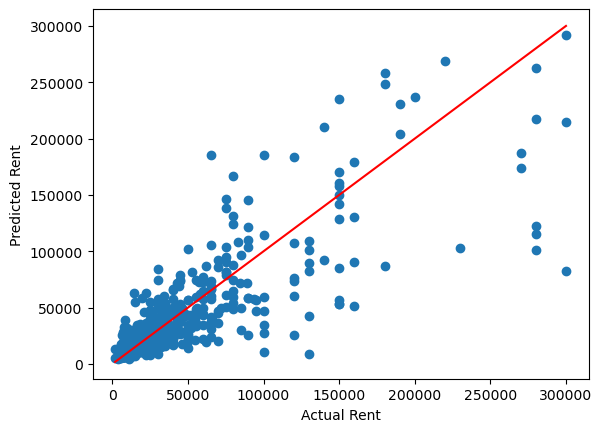

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test_real, y_pred_real)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    color="red"
)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()


In [40]:
dataset = dataset[dataset["Rent"] < 150000]


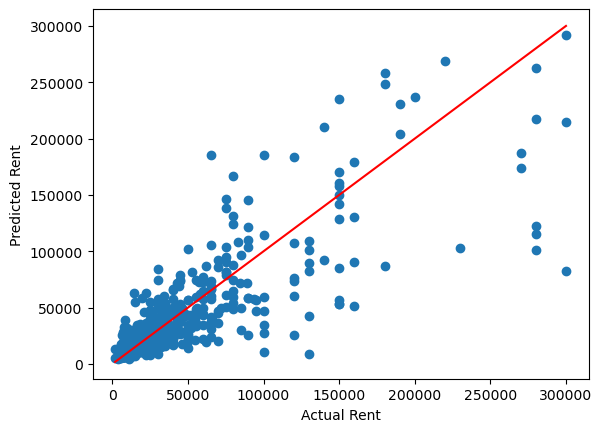

In [41]:
plt.scatter(y_test_real, y_pred_real)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    color="red"
)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()


In [32]:
xgb_model.fit(X_train, y_train)


NameError: name 'xgb_model' is not defined

In [ ]:
# X_train is your feature DataFrame used for training
print(X_train.columns)


Index(['BHK', 'Size', 'Floor', 'Bathroom', 'City_bangalore', 'City_chennai',
       'City_delhi', 'City_hyderabad', 'City_kolkata', 'City_mumbai',
       'City_other', 'Area Locality_andheri west', 'Area Locality_bandra west',
       'Area Locality_banjara hills nh ', 'Area Locality_chembur',
       'Area Locality_chhattarpur', 'Area Locality_chromepet gst road',
       'Area Locality_electronic city', 'Area Locality_gachibowli',
       'Area Locality_goregaon west',
       'Area Locality_jp nagar phase  j p nagar', 'Area Locality_k r puram',
       'Area Locality_khar west', 'Area Locality_kondapur',
       'Area Locality_lajpat nagar ', 'Area Locality_laxmi nagar',
       'Area Locality_madipakkam', 'Area Locality_mahadevapura',
       'Area Locality_manikonda outer ring road', 'Area Locality_medavakkam',
       'Area Locality_miyapur nh ', 'Area Locality_nan',
       'Area Locality_old mahabalipuram road', 'Area Locality_other',
       'Area Locality_perungalathur chennai bypass roa